BCI Competition IV Data Visualization
Loading file: C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\sub1_comp.mat
Keys dalam file .mat:
  train_data: (400000, 62)
  test_data: (200000, 62)
  train_dg: (400000, 5)

=== DATA STRUCTURE ANALYSIS ===

Key: train_data
Shape: (400000, 62)
Data type: int32
Kemungkinan: 400000 channels x 62 samples

Key: test_data
Shape: (200000, 62)
Data type: int16
Kemungkinan: 200000 channels x 62 samples

Key: train_dg
Shape: (400000, 5)
Data type: float64
Kemungkinan: 400000 channels x 5 samples

=== VISUALIZING Subject 1 - BCI Competition IV ===
Menggunakan key: train_data
Shape data: (400000, 62)
Format: 400000 channels, 62 time points


c:\python\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 62, using nperseg = 62
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


MemoryError: Unable to allocate 1.16 TiB for an array with shape (400000, 400000) and data type float64

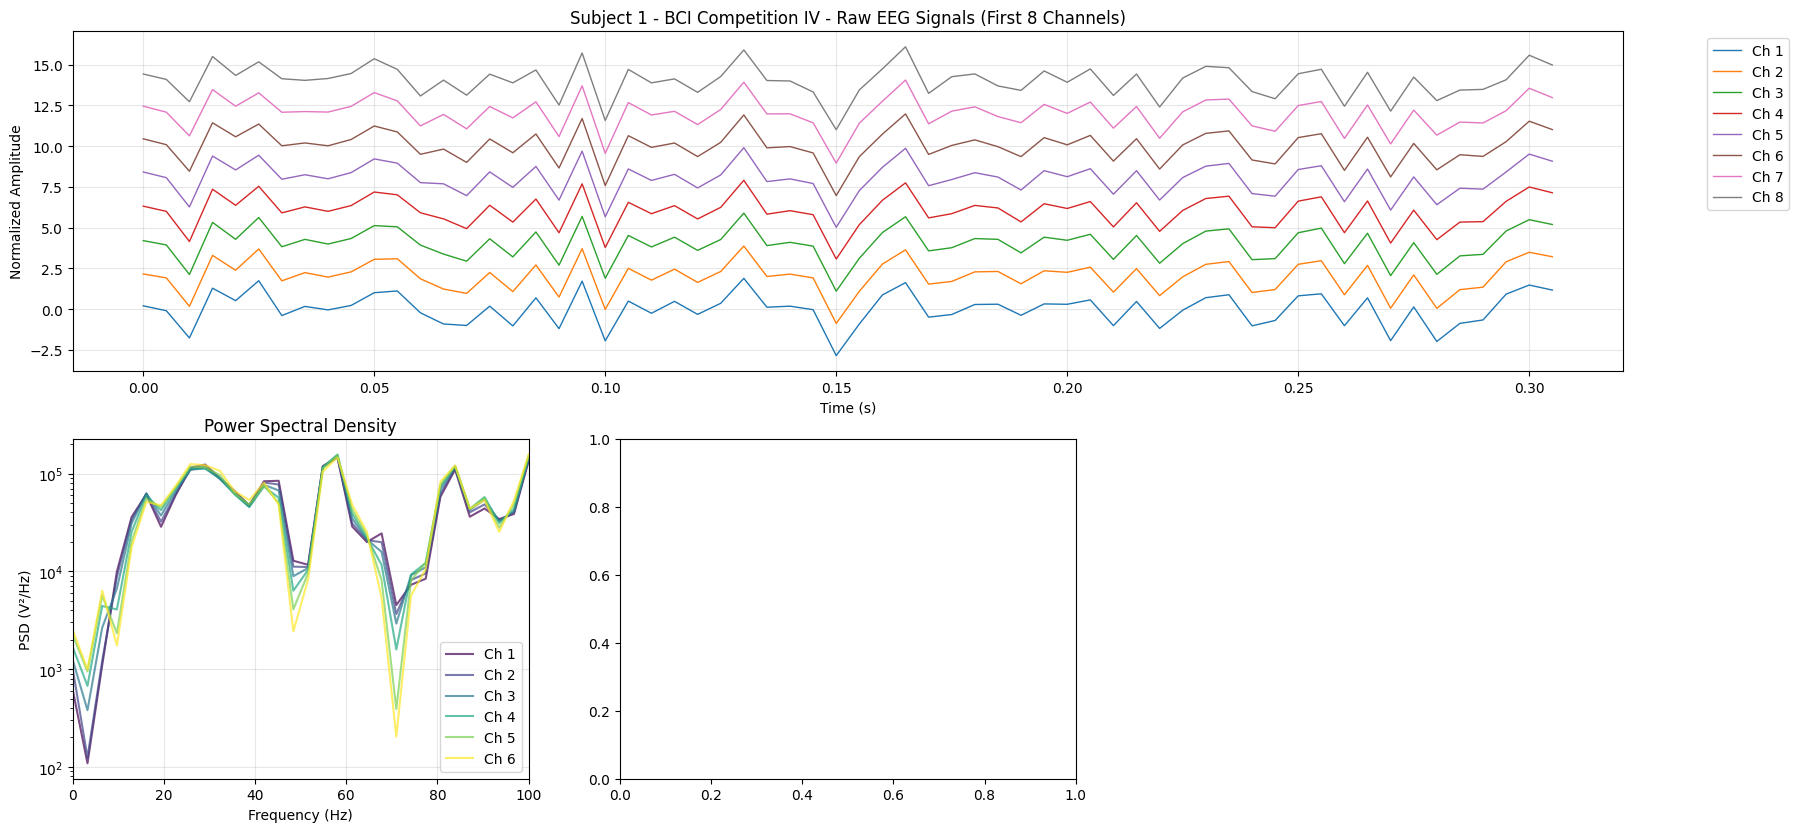

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy import signal
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os

# Load data dari file .mat dengan path spesifik
def load_bci_data(file_path):
    """
    Load data dari BCI Competition IV
    """
    try:
        data = scipy.io.loadmat(file_path)
        print("Keys dalam file .mat:")
        for key in data.keys():
            if not key.startswith('__'):
                print(f"  {key}: {data[key].shape}")
        return data
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

# Analisis struktur data BCI Competition IV
def analyze_data_structure(data):
    """
    Menganalisis struktur data BCI Competition IV
    """
    print("\n=== DATA STRUCTURE ANALYSIS ===")
    
    for key in data.keys():
        if not key.startswith('__'):
            print(f"\nKey: {key}")
            print(f"Shape: {data[key].shape}")
            print(f"Data type: {data[key].dtype}")
            
            # Coba untuk mengekstrak informasi lebih detail
            if len(data[key].shape) == 2:
                print(f"Kemungkinan: {data[key].shape[0]} channels x {data[key].shape[1]} samples")
            elif len(data[key].shape) == 3:
                print(f"Kemungkinan: {data[key].shape[0]} trials x {data[key].shape[1]} channels x {data[key].shape[2]} samples")

# Visualisasi data EEG untuk BCI Competition IV
def visualize_bci_data(data, subject_name, fs=200):
    """
    Visualisasi data EEG dari BCI Competition IV
    """
    print(f"\n=== VISUALIZING {subject_name} ===")
    
    # Cari key yang berisi data EEG
    eeg_data = None
    data_key = None
    
    for key in data.keys():
        if not key.startswith('__') and (len(data[key].shape) == 2 or len(data[key].shape) == 3):
            eeg_data = data[key]
            data_key = key
            break
    
    if eeg_data is None:
        print("Tidak dapat menemukan data EEG dalam file")
        return None
    
    print(f"Menggunakan key: {data_key}")
    print(f"Shape data: {eeg_data.shape}")
    
    # Handle berbagai bentuk data
    if len(eeg_data.shape) == 3:
        # Data 3D: trials x channels x time
        n_trials, n_channels, n_time = eeg_data.shape
        print(f"Format: {n_trials} trials, {n_channels} channels, {n_time} time points")
        
        # Pilih beberapa trial untuk visualisasi
        trial_to_plot = min(2, n_trials - 1)  # Plot trial 0 dan 2
        eeg_trial1 = eeg_data[0]  # Trial pertama
        eeg_trial2 = eeg_data[trial_to_plot]  # Trial lainnya
        
    elif len(eeg_data.shape) == 2:
        # Data 2D: channels x time
        n_channels, n_time = eeg_data.shape
        print(f"Format: {n_channels} channels, {n_time} time points")
        eeg_trial1 = eeg_data
        eeg_trial2 = eeg_data  # Untuk konsistensi
    
    # Buat visualisasi comprehensive
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(3, 3, figure=fig)
    
    time_axis = np.arange(n_time) / fs
    
    # Plot 1: Raw EEG signals (beberapa channel pertama)
    ax1 = fig.add_subplot(gs[0, :])
    channels_to_plot = min(8, n_channels)
    
    for ch in range(channels_to_plot):
        signal_plot = eeg_trial1[ch] if len(eeg_data.shape) == 2 else eeg_trial1[ch, :]
        normalized_signal = (signal_plot - np.mean(signal_plot)) / (np.std(signal_plot) + 1e-8) + ch * 2
        ax1.plot(time_axis, normalized_signal, label=f'Ch {ch+1}', linewidth=1)
    
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Normalized Amplitude')
    ax1.set_title(f'{subject_name} - Raw EEG Signals (First {channels_to_plot} Channels)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Power Spectral Density
    ax2 = fig.add_subplot(gs[1, 0])
    colors = plt.cm.viridis(np.linspace(0, 1, min(6, n_channels)))
    
    for ch in range(min(6, n_channels)):
        signal_psd = eeg_trial1[ch] if len(eeg_data.shape) == 2 else eeg_trial1[ch, :]
        f, Pxx = signal.welch(signal_psd, fs, nperseg=512)
        ax2.semilogy(f, Pxx, color=colors[ch], label=f'Ch {ch+1}', alpha=0.7)
    
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('PSD (V²/Hz)')
    ax2.set_title('Power Spectral Density')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 100)
    
    # Plot 3: Channel Correlation Matrix
    ax3 = fig.add_subplot(gs[1, 1])
    if len(eeg_data.shape) == 2:
        corr_matrix = np.corrcoef(eeg_trial1)
    else:
        corr_matrix = np.corrcoef(eeg_trial1.reshape(n_channels, -1))
    
    im = ax3.imshow(corr_matrix, cmap='coolwarm', aspect='auto', 
                   vmin=-1, vmax=1, interpolation='nearest')
    ax3.set_title('Channel Correlation Matrix')
    ax3.set_xlabel('Channel')
    ax3.set_ylabel('Channel')
    plt.colorbar(im, ax=ax3)
    
    # Plot 4: Channel Variance - Artifact Detection
    ax4 = fig.add_subplot(gs[1, 2])
    if len(eeg_data.shape) == 2:
        variances = np.var(eeg_trial1, axis=1)
    else:
        variances = np.var(eeg_trial1, axis=1)
    
    threshold = np.median(variances) + 2 * np.std(variances)
    colors = ['red' if var > threshold else 'blue' for var in variances]
    
    bars = ax4.bar(range(len(variances)), variances, color=colors, alpha=0.7)
    ax4.axhline(threshold, color='red', linestyle='--', 
                label=f'Artifact Threshold: {threshold:.2f}')
    ax4.set_xlabel('Channel')
    ax4.set_ylabel('Variance')
    ax4.set_title('Channel Variance - Artifact Detection')
    ax4.legend()
    ax4.tick_params(axis='x', rotation=45)
    
    # Plot 5: Time-frequency analysis untuk satu channel
    ax5 = fig.add_subplot(gs[2, 0])
    channel_for_tf = min(0, n_channels - 1)  # Channel pertama
    
    if len(eeg_data.shape) == 2:
        tf_signal = eeg_trial1[channel_for_tf]
    else:
        tf_signal = eeg_trial1[channel_for_tf, :]
    
    f, t, Sxx = signal.spectrogram(tf_signal, fs, nperseg=128, noverlap=64)
    pcm = ax5.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), 
                        shading='gouraud', cmap='viridis')
    ax5.set_ylabel('Frequency [Hz]')
    ax5.set_xlabel('Time [sec]')
    ax5.set_title(f'Time-Frequency (Channel {channel_for_tf + 1})')
    plt.colorbar(pcm, ax=ax5, label='Power (dB)')
    
    # Plot 6: Distribution of amplitudes
    ax6 = fig.add_subplot(gs[2, 1])
    if len(eeg_data.shape) == 2:
        all_data = eeg_trial1.flatten()
    else:
        all_data = eeg_trial1.flatten()
    
    ax6.hist(all_data, bins=100, density=True, alpha=0.7, color='skyblue')
    ax6.set_xlabel('Amplitude')
    ax6.set_ylabel('Density')
    ax6.set_title('Amplitude Distribution')
    ax6.grid(True, alpha=0.3)
    
    # Plot 7: Zoom in to specific time window untuk melihat detail
    ax7 = fig.add_subplot(gs[2, 2])
    zoom_start, zoom_end = 1000, 2000  # Samples
    time_zoom = time_axis[zoom_start:zoom_end]
    
    for ch in range(min(3, n_channels)):
        if len(eeg_data.shape) == 2:
            signal_zoom = eeg_trial1[ch, zoom_start:zoom_end]
        else:
            signal_zoom = eeg_trial1[ch, zoom_start:zoom_end]
        
        ax7.plot(time_zoom, signal_zoom, label=f'Ch {ch+1}', linewidth=1.5)
    
    ax7.set_xlabel('Time (s)')
    ax7.set_ylabel('Amplitude')
    ax7.set_title('Zoomed View (1-10 seconds)')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return eeg_data

# Deteksi artefak detail
def detect_detailed_artifacts(eeg_data, fs=200):
    """
    Deteksi detail berbagai jenis artefak
    """
    print("\n=== DETAILED ARTIFACT ANALYSIS ===")
    
    if len(eeg_data.shape) == 3:
        n_trials, n_channels, n_time = eeg_data.shape
        # Gunakan trial pertama untuk analisis
        data_for_analysis = eeg_data[0]
    else:
        n_channels, n_time = eeg_data.shape
        data_for_analysis = eeg_data
    
    artifact_report = {
        'high_amplitude': [],
        'high_variance': [],
        'line_noise': [],
        'dc_drift': [],
        'flat_channels': []
    }
    
    # Thresholds (dapat disesuaikan)
    amp_threshold = 100  # μV
    var_threshold_multiplier = 3
    dc_threshold = 50    # μV
    flat_threshold = 1   # μV std
    
    variances = np.var(data_for_analysis, axis=1)
    var_threshold = np.median(variances) + var_threshold_multiplier * np.std(variances)
    
    for ch in range(n_channels):
        channel_data = data_for_analysis[ch]
        
        # 1. High amplitude artifacts
        max_amp = np.max(np.abs(channel_data))
        if max_amp > amp_threshold:
            artifact_report['high_amplitude'].append((ch, max_amp))
        
        # 2. High variance artifacts
        if variances[ch] > var_threshold:
            artifact_report['high_variance'].append((ch, variances[ch]))
        
        # 3. DC drift
        mean_val = np.mean(channel_data)
        if abs(mean_val) > dc_threshold:
            artifact_report['dc_drift'].append((ch, mean_val))
        
        # 4. Flat channels (sensor masalah)
        std_val = np.std(channel_data)
        if std_val < flat_threshold:
            artifact_report['flat_channels'].append((ch, std_val))
        
        # 5. Line noise (50 Hz)
        f, Pxx = signal.welch(channel_data, fs, nperseg=512)
        idx_50hz = np.argmin(np.abs(f - 50))
        power_50hz = Pxx[idx_50hz]
        
        # Band sekitar 50 Hz untuk comparison
        idx_band = (f >= 45) & (f <= 55)
        avg_power_around = np.mean(Pxx[idx_band])
        
        if power_50hz > 5 * avg_power_around and power_50hz > 1e-3:
            artifact_report['line_noise'].append((ch, power_50hz))
    
    # Print results
    print("\n--- ARTIFACT REPORT ---")
    for artifact_type, channels in artifact_report.items():
        if channels:
            print(f"\n{artifact_type.upper().replace('_', ' ')}:")
            for ch, value in channels:
                print(f"  Channel {ch+1}: {value:.2f}")
        else:
            print(f"\n{artifact_type.upper().replace('_', ' ')}: None detected")
    
    return artifact_report

# Main execution dengan path spesifik
if __name__ == "__main__":
    # Path spesifik ke file Anda
    file_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\sub1_comp.mat"
    
    print("BCI Competition IV Data Visualization")
    print("=" * 50)
    
    # Cek apakah file exists
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        print("Pastikan path benar dan file exists")
    else:
        print(f"Loading file: {file_path}")
        
        # Load data
        data = load_bci_data(file_path)
        
        if data is not None:
            # Analisis struktur data
            analyze_data_structure(data)
            
            # Visualisasi data
            eeg_data = visualize_bci_data(data, "Subject 1 - BCI Competition IV")
            
            # Analisis artefak detail
            if eeg_data is not None:
                artifact_report = detect_detailed_artifacts(eeg_data)
                
                print("\n=== SUMMARY ===")
                total_artifacts = sum(len(channels) for channels in artifact_report.values())
                print(f"Total artifact channels detected: {total_artifacts}")
                
                # Rekomendasi preprocessing
                print("\n=== RECOMMENDATIONS ===")
                if artifact_report['high_amplitude']:
                    print("- Pertimbangkan rejection trials dengan amplitude tinggi")
                if artifact_report['line_noise']:
                    print("- Gunakan notch filter 50 Hz untuk mengurangi line noise")
                if artifact_report['dc_drift']:
                    print("- Apply high-pass filter (0.5-1 Hz) untuk remove DC drift")
                if artifact_report['flat_channels']:
                    print("- Channel flat mungkin perlu diinterpolasi atau dibuang")

print("\nAnalysis completed!")